<hr>
<center> Control Systems - Ashesi University - January 2026 <br>
<b> Take-home Project for Control Systems </b> <br>
Jonas Matt, Verena Häberle, Prof. Florian Dörfler <br>
Automatic Control Laboratory, ETH Zurich </center>
<hr>

In this notebook, you will find different code fragments to complete the take-home project. <b>

<!-- <blockquote> -->
<b>Activity:</b> Execute the code cells below so that the necessary libraries get imported.
<!-- </blockquote> -->

In [ ]:
# if you run code on google colab these lines will be necessary
!apt-get install gfortran cmake --fix-missing
!apt-get install libblas-dev liblapack-dev

import os
os.environ['BLA_VENDOR']="Generic"
!echo Using $$BLA_VENDOR BLAS implementation

!mkdir figure

!pip install -v slycot
!pip install control
!pip install matplotlib
!pip install ipympl

from google.colab import output
output.enable_custom_widget_manager()

import numpy as np # the standard library for numerics, vectors, matrices
import control as ct # the standard library for basic operations for analysis and design of feedback control systems
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
import sympy as sp # the standard library for symbolic mathematical computations

This example shows you how to use the *sympy* package to compute the jacobian of the function <br>
\begin{equation}
f(s) = \begin{bmatrix}
s_1^2 + s_2 \\ s_1^3 - s_2^2
\end{bmatrix}
\end{equation}
with respect to the variable <br>
\begin{equation}
s=\begin{bmatrix}
s_1\\ s_2
\end{bmatrix}.
\end{equation}
The Jacobian is then evaluated at $s_1 =1$. This will be useful for task T1-i).

In [2]:
s1, s2 = sp.symbols('s1, s2')
s_vec = sp.Array([[s1],[s2]])
f = sp.Matrix([s1**2 + s2, s1**3 - s2**2])
Delta_f = f.jacobian(s_vec)
print(Delta_f)
s_param = {"s1": 1}
Delta_s_param = Delta_f.subs(s_param)
print(Delta_s_param)

Matrix([[2*s1, 1], [3*s1**2, -2*s2]])
Matrix([[2, 1], [3, -2*s2]])


<b> Code fragment for T1 linearization </b>

In [3]:
# define symbolic variables
x, y, z, xdot, ydot, zdot, phi, theta, psi, p, q, r = sp.symbols('x, y, z, xdot, ydot, zdot, phi, theta, psi, p, q, r')
u1,u2,u3,u4, = sp.symbols('u1, u2, u3, u4')
m, g, Ix, Iy, Iz, kx, ky, kz, kp, kq, kr = sp.symbols('m, g, Ix, Iy, Iz, kx, ky, kz, kp, kq, kr')

# define symbolic state, input
states = sp.Array([[x], [y], [z], [xdot], [ydot], [zdot], [phi], [theta], [psi], [p], [q], [r]])
inputs = sp.Array([[u1], [u2], [u3], [u4]])

# nonlinear model equations for derivatives
xddot = (1/m) * (u1 * (sp.sin(psi) * sp.sin(phi) + sp.cos(psi) * sp.cos(phi) * sp.sin(theta)) - kx * xdot)
yddot = (1/m) * (u1 * (sp.cos(psi) * sp.sin(phi) - sp.sin(psi) * sp.cos(phi) * sp.sin(theta)) - ky * ydot)
zddot = (1/m) * (u1 * sp.cos(phi) * sp.cos(theta) - m * g - kz * zdot)
phiddot = (1/Ix) * (u2 - kp * p)
thetaddot = (1/Iy) * (u3 - kq * q)
psiddot = (1/Iz) * (u4 - kr * r)

# Correct drone matrix (state derivative vector): [x_dot, y_dot, z_dot, x_ddot, y_ddot, z_ddot, phi_dot, theta_dot, psi_dot, phi_ddot, theta_ddot, psi_ddot]
drone = sp.Matrix([xdot, ydot, zdot, xddot, yddot, zddot, p, q, r, phiddot, thetaddot, psiddot])

# set physical parameters
param = {"m":0.03, "g":9.81, "kx":4.5e-3, "ky":4.5e-3, "kz":4.5e-3, "Ix":1.5e-5, "Iy":1.5e-5, "Iz":3e-5, "kp":4.5e-4, "kq":4.5e-4, "kr":4.5e-4}

# define equilibrium states (e.g., for hover at origin with zero yaw)
equilibrium_states = {
    x: 0, y: 0, z: 0,
    xdot: 0, ydot: 0, zdot: 0,
    phi: 0, theta: 0, psi: 0,
    p: 0, q: 0, r: 0
}

# define equilibrium inputs (for hover)
# u1_eq = m*g to counteract gravity
u1_eq_val = param["m"] * param["g"]
equilibrium_inputs = {
    u1: u1_eq_val,
    u2: 0,
    u3: 0,
    u4: 0
}

# combine all substitutions into a single dictionary
sub_dict = {**param, **equilibrium_states, **equilibrium_inputs}

# compute symbolic state-space matrices
Asym = drone.jacobian(states)
Bsym = drone.jacobian(inputs)

# substitute all numerical values
A = np.array(Asym.subs(sub_dict), dtype=float)
B = np.array(Bsym.subs(sub_dict), dtype=float)
C = np.eye(12)
C = C[[0,1,2,6],:] # select only x, y, z, phi

# print system matrices A, B
np.set_printoptions(precision=4,suppress=True,linewidth=np.inf)
print('The system matrix A is \n',A)
print('The system matrix B is \n',B)
print(Asym.subs(sub_dict))

The system matrix A is 
 [[  0.     0.     0.     1.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     1.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     1.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.    -0.15   0.     0.     0.     9.81   0.     0.     0.     0.  ]
 [  0.     0.     0.     0.    -0.15   0.     9.81   0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.    -0.15   0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     1.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     1.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     1.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.   -30.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   -30.     0.  ]
 [  0.     0.     

<br>

<b> Code fragment for T2 stability analysis </b>

In [49]:
# compute eigenvalues
eigenvalues = np.linalg.eigvals(A)
print("Eigenvalues:", eigenvalues)

# compute Jordan form
# Hint: To compute the Jordan form of the matrix M, use the command 'M.jordan_form()', which can only be applied if M is a Sympy matrix.
A_sympy = sp.Matrix(A)
P, J = A_sympy.jordan_form()
print("Jordan form:", J)
print("Transformation matrix P:", P)

Eigenvalues: [  0.     0.     0.    -0.15  -0.15  -0.15   0.     0.     0.   -30.   -30.   -15.  ]
Jordan form: Matrix([[-30.0000000000000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, -30.0000000000000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, -15.0000000000000, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, -0.150000000000000, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, -0.150000000000000, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, -0.150000000000000, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1.00000000000000, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1.00000000000000, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Transformation matrix P: Matrix([[0, -0.000365159128978224, 0, -6.66666666666667, 0, 0, 0, 0, 65.4000000000000, 0, 0, 0], [-0.000365159128978224, 0, 0, 0, -6.66666666666667, 0, 65.4000000000000, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, -6.66666666666667, 0, 0, 0, 0, 1.00000000000000, 0], [0, 0.01095477

<br>

<b> Code fragment for T3 forced responses </b>

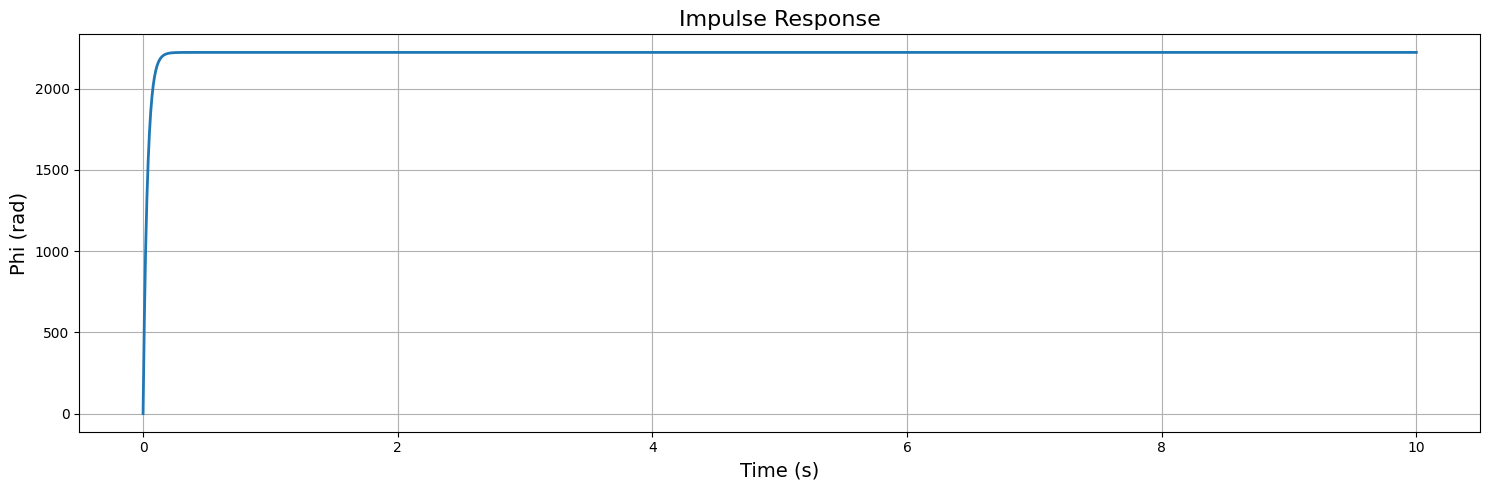

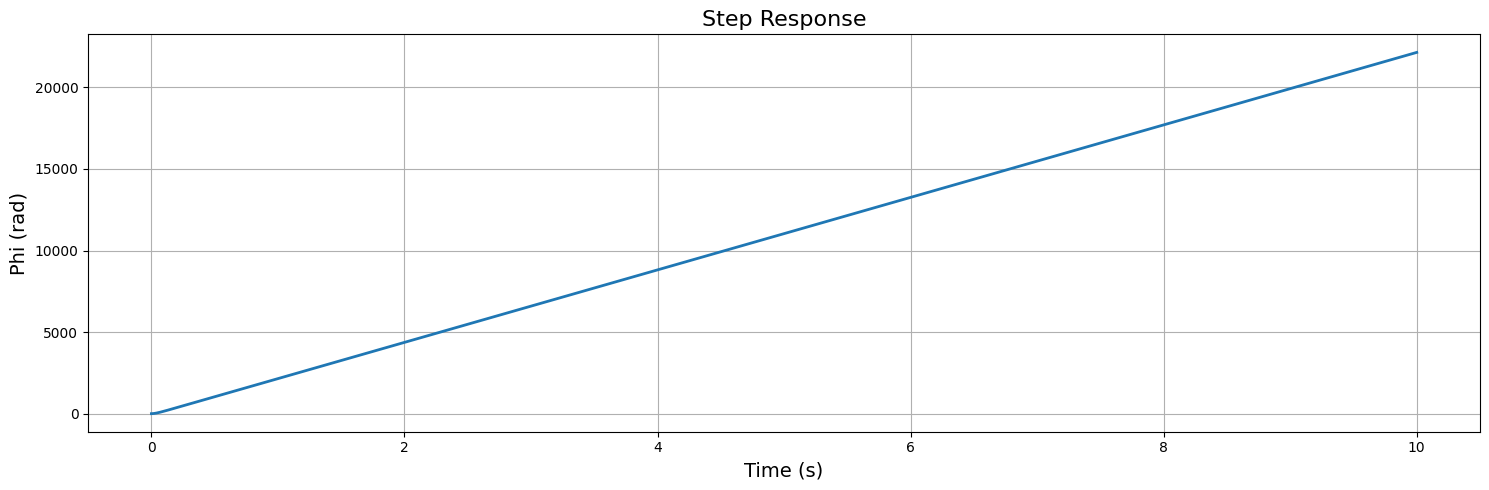

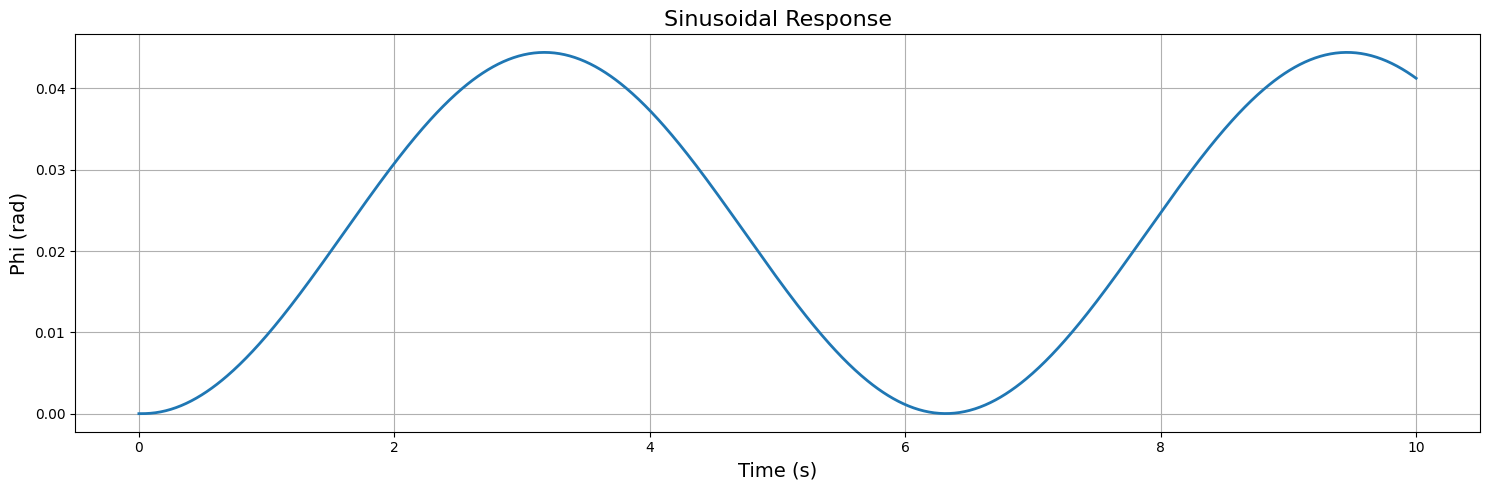

In [50]:
# Define plot function
def plot_func(x, y, xlabel='xlabel', ylabel='ylabel', title='title', n_plots=0, subplot=0):
  plt.figure(figsize=(15, 5))
  if n_plots>1:
    plt.subplot(1, n_plots, subplot)
  plt.plot(x, y, linewidth=2)
  plt.xlabel(xlabel,fontsize=14)
  plt.ylabel(ylabel,fontsize=14)
  plt.title(title,fontsize=16)
  plt.grid()
  plt.tight_layout()

# extracting the rolling dynamics
A_rolling = A[[6, 9], :][:, [6, 9]]  # rows 6,9 and cols 6,9
B_rolling = B[[6, 9], 1:2]  # rows 6,9 and col 1 (u2)
C_rolling = np.array([[1, 0]])  # output is phi
D_rolling = np.array([[0]])
sys_rolling = ct.StateSpace(A_rolling, B_rolling, C_rolling, D_rolling)

# plot impulse response
t_impulse, y_impulse = ct.impulse_response(sys_rolling, T=np.linspace(0, 10, 1000))
plot_func(t_impulse, y_impulse, xlabel='Time (s)', ylabel='Phi (rad)', title='Impulse Response')

# plot step response
t_step, y_step = ct.step_response(sys_rolling, T=np.linspace(0, 10, 1000))
plot_func(t_step, y_step, xlabel='Time (s)', ylabel='Phi (rad)', title='Step Response')

# plot sinusoidal response
t_sin = np.linspace(0, 10, 1000)
u_sin = 1e-5 * np.sin(t_sin)
t_sin, y_sin = ct.forced_response(sys_rolling, T=t_sin, U=u_sin)
plot_func(t_sin, y_sin, xlabel='Time (s)', ylabel='Phi (rad)', title='Sinusoidal Response')

# Show plots
plt.show()

<br>

<b> Code fragment for T4 state-feedback control </b>

In [51]:
# set parameters
m = 0.03
kx = 0.015
kq = 4.5e-4
Iy = 1.5e-5
g = 9.81

# set system matrices
A_x = np.array([[0, 1, 0, 0],
                [0, -kx/m, g, 0],
                [0, 0, 0, 1],
                [0, 0, 0, -kq/Iy]])

B_x = np.array([[0], [0], [0], [1/Iy]])

C_x = np.array([[1, 0, 0, 0]])

D_x = np.array([[0]])

# analyze stability
eigenvalues_Ax = np.linalg.eigvals(A_x)
print("Eigenvalues of A_x:", eigenvalues_Ax)

# analyze controllability
ctrb_matrix = ct.ctrb(A_x, B_x)
rank_ctrb = np.linalg.matrix_rank(ctrb_matrix)
print("Controllability matrix rank:", rank_ctrb, "System dimension:", A_x.shape[0])
if rank_ctrb == A_x.shape[0]:
    print("System is controllable")
else:
    print("System is not controllable")

Eigenvalues of A_x: [  0.   -0.5   0.  -30. ]
Controllability matrix rank: 4 System dimension: 4
System is controllable


In [52]:
# Pole Placement
## 1. Convert to reachable canonical form, x -> z coordinates; z = Tx
sys_x = ct.StateSpace(A_x, B_x, C_x, D_x)
sys_z, T = ct.canonical_form(sys_x, form='reachable')
a_coeff = sys_z.A[0,:]
print("Canonical form of A_x:", a_coeff)

## 2. desired characteristic polynomial
desired_poles = np.array([-100, -50, -10, -10])
q_coeff = np.poly(desired_poles)[1:]
print("Desired characteristic equation:", q_coeff)

## 3. feedback K; U = -Kz = -KTx
K_z = np.array([q_coeff - a_coeff])
K = np.matmul(K_z, T) # Convert K to original coordinates
print("State feedback gain K transformation coords:", K_z)
print("State feedback gain K original coords:", K)

## 4. Compare to Ackermann's Formula
K_acker = np.array([ct.place_acker(A_x, B_x, desired_poles)])
print("State feedback gain K Ackermanns':", K_acker)

Canonical form of A_x: [-30.5 -15.   -0.   -0. ]
Desired characteristic equation: [   170.   8100. 115000. 500000.]
State feedback gain K transformation coords: [[   200.5   8115.  115000.  500000. ]]
State feedback gain K original coords: [[0.7645 0.1697 0.1202 0.003 ]]
State feedback gain K Ackermanns': [[0.7645 0.1697 0.1202 0.0021]]


<b> Code fragment for T5 augmented state-feedback control </b>

Augmented state feedback gain K_aug: [ 0.9404  0.182   0.1228  0.0021 -0.7645]
State feedback gain K: [[0.9404 0.182  0.1228 0.0021]]
Integral feedback gain Ki: [[-0.7645]]


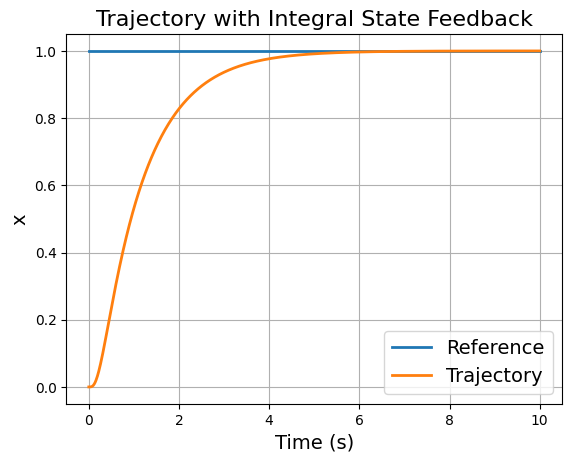

In [53]:
# integral control
# 1. augment the system with integral state
n = 4 # Dimension of the 'x' state vector
A_aug = np.block([[A_x, np.zeros((n, 1))],
                  [-C_x, np.zeros((1, 1))]])
B_aug = np.block([[B_x], [-D_x]])

# 2. design state feedback for augmented system
desired_poles_aug = np.array([-100, -50, -10, -10, -1]) # Added one more pole for the augmented 5-state system
K_aug = ct.acker(A_aug, B_aug, desired_poles_aug) # ct.acker returns a 1xN array directly
print("Augmented state feedback gain K_aug:", K_aug)

# 3. Extract K and Ki from K_aug, ensuring correct shapes for matrix multiplication
K = K_aug[:n].reshape(1, n)
Ki = K_aug[n].reshape(1,1)

print("State feedback gain K:", K)
print("Integral feedback gain Ki:", Ki)

# simulate with reference r = 1
# Construct the closed-loop system matrices using A_x, B_x, C_x       , 0          ]]
A_cl = np.block([[A_x - B_x @ K, -B_x @ Ki],
                 [-C_x, np.array([[0]])]]) # Ensure 0 is a 1x1 matrix

# B_cl: reference input r feeds into the integral state equation
B_cl = np.array([[0], [0], [0], [0], [1]]) # B_cl is (5,1)

# C_cl: output is x (first state of A_x), so C_x followed by 0 for integral state
C_cl = np.block([C_x, np.array([[0]])]) # C_cl is (1,5)
D_cl = np.array([[0]]) # D_cl is (1,1)

sys_aug = ct.StateSpace(A_cl, B_cl, C_cl, D_cl)

T_ref = np.linspace(0, 10, 1000)
# Initial conditions for the 5 augmented states [x_0, x_dot_0, phi_0, p_0, x_int_0]
t_pos, y_out = ct.step_response(sys_aug, T=T_ref, X0=np.array([0, 0, 0, 0, 0]))
# y_out is (num_outputs, num_time_steps). Here num_outputs is 1.
x_pos = y_out # extract just the x position (first state, which is the output of C_cl)

# Plotting
plt.figure()
plt.plot(T_ref, np.ones(T_ref.shape), linewidth=2, label="Reference")
plt.plot(t_pos, x_pos, linewidth=2, label="Trajectory") # Plotting full trajectory now
plt.legend(loc ="lower right",fontsize=14)
plt.xlabel("Time (s)",fontsize=14)
plt.ylabel("x",fontsize=14)
plt.title("Trajectory with Integral State Feedback",fontsize=16)
plt.grid()
#plt.savefig('figure/traj_x.png',bbox_inches='tight')
plt.show()

Feedforward gain N_x: [[1. 0. 0. 0.]]
Feedforward gain N_u: 0.0
Feedforward gain N: [[0.7645]]


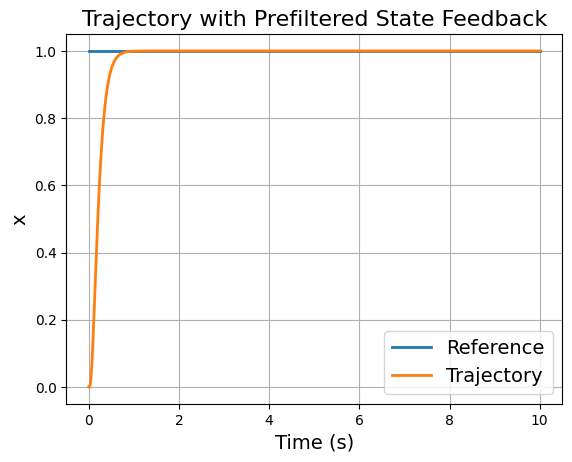

In [40]:
# feedforward & feedback control
# use the state feedback from T4 (without augmentation)
K_t4 = np.array([ct.place_acker(A_x, B_x, np.array([-100, -50, -10, -10]))])
A_cl_t4 = A_x - B_x @ K_t4

# compute feedforward gain for step tracking
M_matrix = np.block([[A_x, B_x], [C_x, D_x]])
m,n = M_matrix.shape
M_ss = (np.linalg.inv(M_matrix)) @ np.block([[np.zeros((n-1, 1))],[1]])
N_x = np.array([M_ss[:n-1, 0]])
N_u = M_ss[n-1, 0]
N = N_u + K_t4@N_x.T
print("Feedforward gain N_x:", N_x)
print("Feedforward gain N_u:", N_u)
print("Feedforward gain N:", N)

# closed-loop system with feedforward: u = N*r - K*x
A_ffcl = A_x - B_x @ K_t4
sys_ffcl = ct.StateSpace(A_ffcl, N * B_x, C_x, D_x)

T_ref = np.linspace(0, 10, 1000)
t_pos, x_pos = ct.step_response(sys_ffcl, T=T_ref)

plt.figure()
plt.plot(T_ref, np.ones_like(T_ref), linewidth=2)        # reference r = 1
plt.plot(t_pos, x_pos, linewidth=2)                      # output y = x position
plt.legend(["Reference", "Trajectory"], loc="lower right", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("x", fontsize=14)
plt.title("Trajectory with Prefiltered State Feedback", fontsize=16)
plt.grid()
plt.show()

<br>

<b> Code fragments for T6 observer-based control </b>

State feedback gain K: [[0.     0.0002 0.0032 0.    ]]
Observer gain L: [[  73.85  ]
 [1817.9225]
 [1535.5759]
 [  17.1254]]


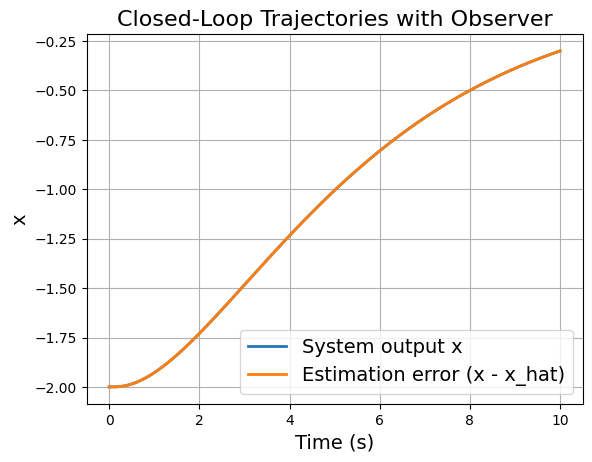

In [54]:
# set model parameters
m = 0.03
kx = 4.5e-3
g = 9.81
Iy = 1.5e-5
kq = 4.5e-4

# set system matrices
A_x = np.array([[0, 1, 0, 0],
                [0, -kx/m, g, 0],
                [0, 0, 0, 1],
                [0, 0, 0, -kq/Iy]])

B_x = np.array([[0], [0], [0], [1/Iy]])

C_x = np.array([[1, 0, 0, 0]])

D_x = np.array([[0]])

# design of the state-feedback controller
K_poles = np.array([-0.3, -0.4, -10, -20])
K = ct.place(A_x, B_x, K_poles)
print("State feedback gain K:", K)

# design of the observer
L_poles = np.array([-23, -26, -27, -28])
L = ct.place(A_x.T, C_x.T, L_poles).T
print("Observer gain L:", L)

# augmented system: [x_actual; x_estimated]
A_aug = np.block([[A_x - B_x @ K, B_x @ K],
                  [np.zeros((4, 4)), A_x - L @ C_x]])
B_aug = np.block([[np.zeros((4, 1))],
                  [L]])
C_aug = np.block([[C_x, -C_x]])  # output: x - x_hat (estimation error)

sys_aug = ct.StateSpace(A_aug, B_aug, C_aug, np.array([[0]]))

# plot the closed-loop trajectories
plt.figure()
t_ref = np.linspace(0, 10, 1000)
X0 = np.array([-2, 0, 0, 0, 0, 0, 0, 0])  # initial conditions: [actual_x; estimated_x]
t_aug, y_error_est, x_full_states = ct.initial_response(sys_aug, T=t_ref, X0=X0, return_x=True)

# x_full_states is an array of shape (num_states, num_time_steps)
# The first state of the actual system is x_full_states[0, :]
x_actual_pos = x_full_states[0, :]

plt.plot(t_ref, x_actual_pos, linewidth=2, label='System output x')
plt.plot(t_ref, y_error_est, linewidth=2, label='Estimation error (x - x_hat)')
plt.legend(loc="lower right", fontsize=14)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('x', fontsize=14)
plt.title('Closed-Loop Trajectories with Observer', fontsize=16)
plt.grid()
#plt.savefig('figure/closed_loop_traj.png',bbox_inches='tight')
plt.show()